# Sear nucleation pressure-sweep analysis

This notebook compares the fixed-size pressure sweeps for **ZIF-71 (RHO)** and **ZIF-67 (SOD)**. The simulation code fits the stretched-exponential survival model

$$S(t)=\exp[-(t/\tau)^\beta].$$

Here, $\tau$ is the characteristic first-nucleation time and $\beta$ controls the survival-curve shape. The code's classification is: rate-less ($\beta<0.7$), intermediate ($0.7\leq\beta<0.9$), classical ($0.9\leq\beta\leq1.1$), and super-exponential ($\beta>1.1$).

> Important: each material has only one fitted row at each pressure, and the materials differ in node count. The cross-material plots are descriptive, not controlled hypothesis tests.

In [1]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
from scipy.stats import linregress, spearmanr

pd.set_option("display.max_columns", None)
pd.set_option("display.precision", 4)
try:
    plt.style.use("seaborn-v0_8-whitegrid")
except OSError:  # Matplotlib < 3.6
    plt.style.use("seaborn-whitegrid")
plt.rcParams.update({"font.size": 15, "axes.titlesize": 18, "axes.labelsize": 16,
                     "xtick.labelsize": 14, "ytick.labelsize": 14,
                     "legend.fontsize": 13, "legend.title_fontsize": 14,
                     "figure.titlesize": 21, "lines.linewidth": 3.2,
                     "lines.markersize": 10, "axes.linewidth": 1.5})
COLORS = {"ZIF-71 (RHO)": "#0072B2", "ZIF-67 (SOD)": "#D55E00"}
MARKERS = {"ZIF-71 (RHO)": "o", "ZIF-67 (SOD)": "s"}
SAVE_FIGURES = True  # Write 300-dpi PNG files beside this notebook.
EXPORT_TABLES = True  # Write analysis CSV files beside this notebook.

c:\Users\danim\anaconda3\lib\site-packages\scipy\__init__.py:146: UserWarning: A NumPy version >=1.16.5 and <1.23.0 is required for this version of SciPy (detected version 1.24.3
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


## Load and validate the two result files

In [2]:
def find_analysis_dir():
    # Works when launched from the repository root, this folder, or a descendant.
    for start in [Path.cwd(), *Path.cwd().parents]:
        direct = start / "RHO"
        nested = start / "ZENODO_repository" / "nucleation" / "Analysis" / "RHO"
        if direct.is_dir() and (start / "SOD").is_dir():
            return start
        if nested.is_dir():
            return nested.parent
    raise FileNotFoundError("Could not locate ZENODO_repository/nucleation/Analysis.")

ANALYSIS_DIR = find_analysis_dir()
FILES = {
    "ZIF-71 (RHO)": ANALYSIS_DIR / "RHO" / "zif71_sear_pressure_sweep_results_26-27-28-29-30-31.csv",
    "ZIF-67 (SOD)": ANALYSIS_DIR / "SOD" / "zif67_sod_sear_pressure_sweep_results_24-25-26-27-28-29.csv",
}
required = {"growth_level", "n_nodes", "beta", "tau", "r2", "rmse",
            "t_median", "mean_first_time", "std_first_time", "n_nucleated",
            "nucleation_rate", "nucleation_regime", "pressure"}

frames = []
for material, path in FILES.items():
    frame = pd.read_csv(path)
    missing = required.difference(frame.columns)
    if missing:
        raise ValueError(f"{path.name} is missing columns: {sorted(missing)}")
    frame.insert(0, "material", material)
    frames.append(frame)

df = (pd.concat(frames, ignore_index=True)
        .sort_values(["material", "pressure"])
        .reset_index(drop=True))
print(f"Loaded {len(df)} rows from {len(FILES)} files in {ANALYSIS_DIR}")
df

Loaded 12 rows from 2 files in c:\Users\danim\OneDrive\Escritorio\year 2024\Stochastic model\LIAM\ZENODO_repository\nucleation\Analysis


,material,growth_level,n_nodes,beta,tau,r2,rmse,t_median,mean_first_time,std_first_time,n_nucleated,nucleation_rate,nucleation_regime,pressure
0,ZIF-67 (SOD),7,855,0.7877,18.1962,0.9921,0.0172,13.0,21.5800,28.5237,50,1.00,Intermediate,24.0
1,ZIF-67 (SOD),7,855,0.7099,26.5674,0.9869,0.0217,17.0,33.7200,45.6193,50,1.00,Intermediate,25.0
2,ZIF-67 (SOD),7,855,0.8192,17.9798,0.9825,0.0232,14.5,22.8800,36.0253,50,1.00,Intermediate,26.0
3,ZIF-67 (SOD),7,855,0.5470,28.2319,0.9797,0.0218,16.5,47.8958,82.0506,48,0.96,Rate-less (Sear),27.0
4,ZIF-67 (SOD),7,855,0.6357,24.9773,0.9822,0.0231,14.5,35.6800,54.2429,50,1.00,Rate-less (Sear),28.0
5,ZIF-67 (SOD),7,855,0.7285,32.1049,0.8615,0.0202,18.0,134.1400,696.0083,50,1.00,Intermediate,29.0
6,ZIF-71 (RHO),7,1695,0.8844,6.5519,0.9837,0.0316,4.0,7.2400,7.2043,50,1.00,Intermediate,26.0
7,ZIF-71 (RHO),7,1695,0.8574,8.7033,0.9691,0.0412,6.0,9.1600,9.1507,50,1.00,Intermediate,27.0
8,ZIF-71 (RHO),7,1695,0.8470,4.4149,0.9818,0.0315,4.0,5.0600,5.2322,50,1.00,Intermediate,28.0
9,ZIF-71 (RHO),7,1695,0.8542,10.3376,0.9868,0.0261,8.0,11.6600,12.9300,50,1.00,Intermediate,29.0


In [3]:
def classify_beta(beta):
    if pd.isna(beta): return "Unknown"
    if beta < 0.7: return "Rate-less (Sear)"
    if beta < 0.9: return "Intermediate"
    if beta <= 1.1: return "Classical"
    return "Super-exponential"

checks = pd.DataFrame({
    "check": ["missing values", "duplicate material-pressure pairs", "beta <= 0",
              "tau <= 0", "R2 outside [0, 1]", "rate outside [0, 1]"],
    "count": [df.isna().sum().sum(), df.duplicated(["material", "pressure"]).sum(),
              (df.beta <= 0).sum(), (df.tau <= 0).sum(), (~df.r2.between(0, 1)).sum(),
              (~df.nucleation_rate.between(0, 1)).sum()]
})
df["regime_recalculated"] = df.beta.map(classify_beta)
df["regime_matches"] = df.nucleation_regime.eq(df.regime_recalculated)
display(checks)
print(f"Regime labels matching the generating-code thresholds: {df.regime_matches.sum()}/{len(df)}")
if not df.regime_matches.all():
    display(df.loc[~df.regime_matches, ["material", "pressure", "beta", "nucleation_regime", "regime_recalculated"]])

,check,count
0,missing values,0
1,duplicate material-pressure pairs,0
2,beta <= 0,0
3,tau <= 0,0
4,"R2 outside [0, 1]",0
5,"rate outside [0, 1]",0


Regime labels matching the generating-code thresholds: 12/12


## Derived quantities and compact tables

The fitted median is $t_{50}=\tau(\ln 2)^{1/\beta}$. Its difference from the observed simulation median is a useful model diagnostic. `inv_tau` is a characteristic frequency, not the stored nucleated fraction (`nucleation_rate`).

In [4]:
df["weibull_median"] = df.tau * np.log(2) ** (1 / df.beta)
df["median_residual"] = df.t_median - df.weibull_median
df["median_relative_error_pct"] = 100 * df.median_residual / df.t_median
df["inv_tau"] = 1 / df.tau
df["cv_first_time"] = df.std_first_time / df.mean_first_time

overview = (df.groupby("material", observed=True)
    .agg(pressures=("pressure", "count"), pressure_min=("pressure", "min"),
         pressure_max=("pressure", "max"), nodes=("n_nodes", "first"),
         beta_mean=("beta", "mean"), tau_median=("tau", "median"),
         r2_min=("r2", "min"), nucleated_min=("nucleation_rate", "min")))
display(overview)
display(df[["material", "pressure", "beta", "tau", "t_median", "weibull_median",
            "median_relative_error_pct", "r2", "rmse", "nucleation_rate", "nucleation_regime"]])

,pressures,pressure_min,pressure_max,nodes,beta_mean,tau_median,r2_min,nucleated_min
material,,,,,,,,
ZIF-67 (SOD),6,24.0,29.0,855,0.7047,25.7724,0.8615,0.96
ZIF-71 (RHO),6,26.0,31.0,1695,0.8421,7.7499,0.9691,1.00


,material,pressure,beta,tau,t_median,weibull_median,median_relative_error_pct,r2,rmse,nucleation_rate,nucleation_regime
0,ZIF-67 (SOD),24.0,0.7877,18.1962,13.0,11.4264,12.1050,0.9921,0.0172,1.00,Intermediate
1,ZIF-67 (SOD),25.0,0.7099,26.5674,17.0,15.8541,6.7407,0.9869,0.0217,1.00,Intermediate
2,ZIF-67 (SOD),26.0,0.8192,17.9798,14.5,11.4940,20.7308,0.9825,0.0232,1.00,Intermediate
3,ZIF-67 (SOD),27.0,0.5470,28.2319,16.5,14.4461,12.4476,0.9797,0.0218,0.96,Rate-less (Sear)
4,ZIF-67 (SOD),28.0,0.6357,24.9773,14.5,14.0326,3.2233,0.9822,0.0231,1.00,Rate-less (Sear)
5,ZIF-67 (SOD),29.0,0.7285,32.1049,18.0,19.4123,-7.8461,0.8615,0.0202,1.00,Intermediate
6,ZIF-71 (RHO),26.0,0.8844,6.5519,4.0,4.3290,-8.2245,0.9837,0.0316,1.00,Intermediate
7,ZIF-71 (RHO),27.0,0.8574,8.7033,6.0,5.6758,5.4039,0.9691,0.0412,1.00,Intermediate
8,ZIF-71 (RHO),28.0,0.8470,4.4149,4.0,2.8642,28.3957,0.9818,0.0315,1.00,Intermediate
9,ZIF-71 (RHO),29.0,0.8542,10.3376,8.0,6.7309,15.8636,0.9868,0.0261,1.00,Intermediate


## Pressure dependence

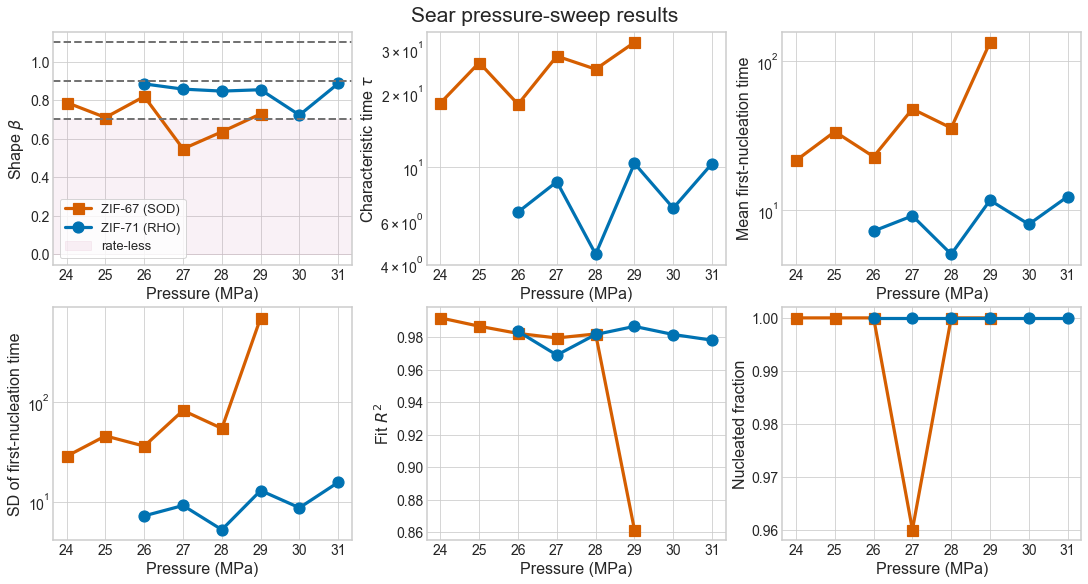

In [5]:
panels = [
    ("beta", r"Shape $\beta$", False),
    ("tau", r"Characteristic time $\tau$", True),
    ("mean_first_time", "Mean first-nucleation time", True),
    ("std_first_time", "SD of first-nucleation time", True),
    ("r2", r"Fit $R^2$", False),
    ("nucleation_rate", "Nucleated fraction", False),
]
fig, axes = plt.subplots(2, 3, figsize=(15, 8), constrained_layout=True)
for ax, (column, ylabel, log_y) in zip(axes.flat, panels):
    for material, group in df.groupby("material", sort=False):
        ax.plot(group.pressure, group[column], marker=MARKERS[material], ms=11, lw=3.2,
                markeredgewidth=1.2, color=COLORS[material], label=material)
    if column == "beta":
        ax.axhspan(0, 0.7, color="#CC79A7", alpha=.10, label="rate-less")
        for boundary in (0.7, 0.9, 1.1): ax.axhline(boundary, color="0.45", ls="--", lw=2)
    if log_y: ax.set_yscale("log")
    ax.set(xlabel="Pressure (MPa)", ylabel=ylabel)
    ax.xaxis.set_major_locator(MaxNLocator(integer=True))
axes[0, 0].legend(frameon=True)
fig.suptitle("Sear pressure-sweep results")
if SAVE_FIGURES: fig.savefig(ANALYSIS_DIR / "sear_pressure_sweep_overview.png", dpi=300, bbox_inches="tight")
plt.show()

## Fit diagnostics

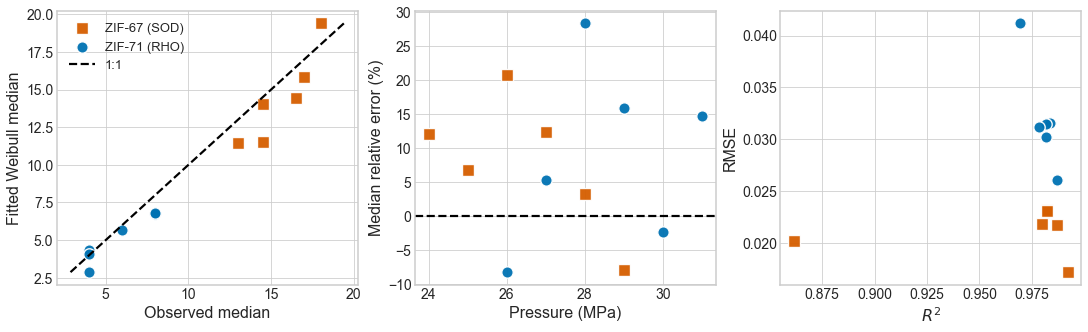

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5), constrained_layout=True)
for material, group in df.groupby("material", sort=False):
    style = dict(marker=MARKERS[material], s=130, linewidths=1.4, edgecolors="white",
                 color=COLORS[material], label=material, alpha=.95)
    axes[0].scatter(group.t_median, group.weibull_median, **style)
    axes[1].scatter(group.pressure, group.median_relative_error_pct, **style)
    axes[2].scatter(group.r2, group.rmse, **style)
lo = min(df.t_median.min(), df.weibull_median.min())
hi = max(df.t_median.max(), df.weibull_median.max())
axes[0].plot([lo, hi], [lo, hi], "k--", lw=2.2, label="1:1")
axes[0].set(xlabel="Observed median", ylabel="Fitted Weibull median")
axes[1].axhline(0, color="k", ls="--", lw=2.2)
axes[1].set(xlabel="Pressure (MPa)", ylabel="Median relative error (%)")
axes[2].set(xlabel=r"$R^2$", ylabel="RMSE")
axes[0].legend()
if SAVE_FIGURES: fig.savefig(ANALYSIS_DIR / "sear_fit_diagnostics.png", dpi=300, bbox_inches="tight")
plt.show()

## Reconstructed fitted survival curves

These curves are reconstructed from the CSV's fitted parameters; they are **not** empirical Kaplan–Meier curves. Raw replicate-level first-passage times would be required to show uncertainty bands or refit the model.

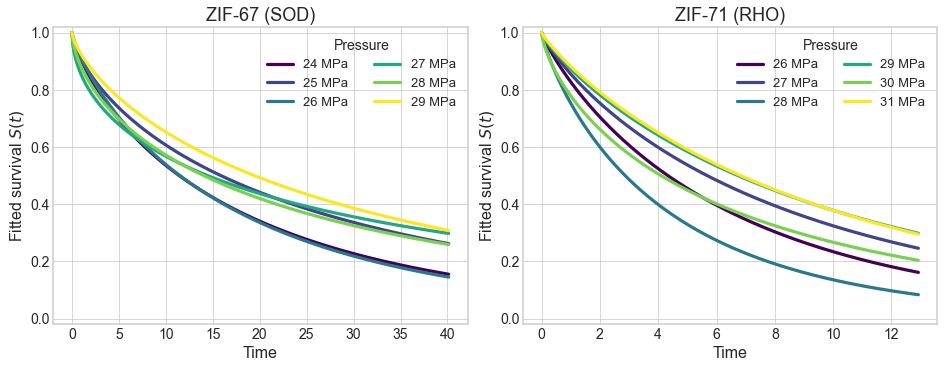

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5), constrained_layout=True)
for ax, (material, group) in zip(axes, df.groupby("material", sort=False)):
    t_max = 1.25 * max(group.tau.max(), group.t_median.max())
    t = np.linspace(0, t_max, 500)
    cmap = plt.get_cmap("viridis")
    norm = plt.Normalize(group.pressure.min(), group.pressure.max())
    for row in group.itertuples():
        survival = np.exp(-(t / row.tau) ** row.beta)
        ax.plot(t, survival, color=cmap(norm(row.pressure)), lw=3.2, label=f"{row.pressure:g} MPa")
    ax.set(title=material, xlabel="Time", ylabel=r"Fitted survival $S(t)$", ylim=(-.02, 1.02))
    ax.legend(title="Pressure", ncol=2)
if SAVE_FIGURES: fig.savefig(ANALYSIS_DIR / "sear_reconstructed_survival.png", dpi=300, bbox_inches="tight")
plt.show()

## Descriptive trend statistics

OLS slopes and Spearman correlations summarize direction and monotonicity. With only six pressure points per material, use the p-values as diagnostics rather than definitive evidence; no multiple-testing correction is applied.

In [8]:
def trend_table(data, metrics):
    rows = []
    for material, group in data.groupby("material", sort=False):
        for metric in metrics:
            clean = group[["pressure", metric]].dropna()
            ols = linregress(clean.pressure, clean[metric])
            rho, p_spearman = spearmanr(clean.pressure, clean[metric])
            rows.append({"material": material, "metric": metric, "n": len(clean),
                         "OLS slope / MPa": ols.slope, "OLS R2": ols.rvalue**2,
                         "OLS p": ols.pvalue, "Spearman rho": rho,
                         "Spearman p": p_spearman})
    return pd.DataFrame(rows)

trends = trend_table(df, ["beta", "tau", "mean_first_time", "inv_tau", "nucleation_rate"])
display(trends)
if EXPORT_TABLES:
    trends.to_csv(ANALYSIS_DIR / "sear_pressure_trend_statistics.csv", index=False)

c:\Users\danim\anaconda3\lib\site-packages\scipy\stats\stats.py:4484: SpearmanRConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(SpearmanRConstantInputWarning())


,material,metric,n,OLS slope / MPa,OLS R2,OLS p,Spearman rho,Spearman p
0,ZIF-67 (SOD),beta,6,-0.0226,0.1780,0.4047,-0.3714,0.4685
1,ZIF-67 (SOD),tau,6,2.1436,0.5079,0.1120,0.6000,0.2080
2,ZIF-67 (SOD),mean_first_time,6,16.9627,0.5537,0.0899,0.8857,0.0188
3,ZIF-67 (SOD),inv_tau,6,-0.0038,0.4648,0.1358,-0.6000,0.2080
4,ZIF-67 (SOD),nucleation_rate,6,-0.0011,0.0171,0.8047,-0.1309,0.8047
5,ZIF-71 (RHO),beta,6,-0.0110,0.1152,0.5105,-0.0857,0.8717
6,ZIF-71 (RHO),tau,6,0.5441,0.1876,0.3909,0.4857,0.3287
7,ZIF-71 (RHO),mean_first_time,6,0.8211,0.3125,0.2488,0.6000,0.2080
8,ZIF-71 (RHO),inv_tau,6,-0.0089,0.1152,0.5104,-0.4857,0.3287
9,ZIF-71 (RHO),nucleation_rate,6,0.0000,0.0000,1.0000,NaN,NaN


## Regime map and notable rows

In [9]:
regime_counts = (df.groupby(["material", "nucleation_regime"], observed=True)
                   .size().rename("count").reset_index())
display(regime_counts)
if EXPORT_TABLES:
    regime_counts.to_csv(ANALYSIS_DIR / "sear_regime_counts.csv", index=False)

flags = df.loc[(df.r2 < 0.95) | (df.nucleation_rate < 1) |
               (df.median_relative_error_pct.abs() > 25),
               ["material", "pressure", "beta", "tau", "r2", "rmse",
                "n_nucleated", "nucleation_rate", "median_relative_error_pct", "nucleation_regime"]]
print("Rows flagged by: R2 < 0.95, incomplete nucleation, or |median error| > 25%")
display(flags if len(flags) else pd.DataFrame({"result": ["No rows flagged"]}))
if EXPORT_TABLES:
    flags.to_csv(ANALYSIS_DIR / "sear_flagged_results.csv", index=False)

,material,nucleation_regime,count
0,ZIF-67 (SOD),Intermediate,4
1,ZIF-67 (SOD),Rate-less (Sear),2
2,ZIF-71 (RHO),Intermediate,6


Rows flagged by: R2 < 0.95, incomplete nucleation, or |median error| > 25%


,material,pressure,beta,tau,r2,rmse,n_nucleated,nucleation_rate,median_relative_error_pct,nucleation_regime
3,ZIF-67 (SOD),27.0,0.5470,28.2319,0.9797,0.0218,48,0.96,12.4476,Rate-less (Sear)
5,ZIF-67 (SOD),29.0,0.7285,32.1049,0.8615,0.0202,50,1.00,-7.8461,Intermediate
8,ZIF-71 (RHO),28.0,0.8470,4.4149,0.9818,0.0315,50,1.00,28.3957,Intermediate


In [10]:
# Export the enriched table used by this notebook.
if EXPORT_TABLES:
    out = ANALYSIS_DIR / "sear_pressure_sweep_enriched.csv"
    df.to_csv(out, index=False)
    print(f"Saved {out}")
    print("Saved trend statistics, regime counts, and flagged-row CSV files.")
if SAVE_FIGURES:
    print("Saved three 300-dpi PNG figures.")

Saved c:\Users\danim\OneDrive\Escritorio\year 2024\Stochastic model\LIAM\ZENODO_repository\nucleation\Analysis\sear_pressure_sweep_enriched.csv
Saved trend statistics, regime counts, and flagged-row CSV files.
Saved three 300-dpi PNG figures.
